# Walk-forward validation of a DIRECTIONAL regime-gating rule

Direct follow-up to `combined_regime_filter_walk_forward.ipynb`, which
walk-forward tested a regime-gate built on the direction-agnostic 4-regime
scheme (Trending/Choppy x High/Low-Vol) and found it added no real edge
(pooled `trade_sharpe_lb` gap was z~0.33 -- noise).

Since then, `strategy_performance_by_regime.ipynb` was extended with a
**directional** 6-regime scheme (+DI vs -DI splits Trending into Trending
Up / Trending Down) and found something the 4-regime scheme couldn't see:
across Donchian/SuperTrend (the two trend-following mechanisms in this
program's combined portfolio), `trade_sharpe_lb` is consistently *worse* in
Trending Up/High-Vol (melt-up) than in Trending Down/High-Vol (crash) --
the opposite of the "follows the dip down" hypothesis that started this
whole line of work, and specific enough (a genuine asymmetry, not just
"high vol is bad") that it's worth testing properly rather than assuming it
generalizes.

**This notebook asks the same honest question the first walk-forward did**:
does a regime-gate built on this sharper, directional distinction survive
out-of-sample testing, or is it the same kind of single-split artifact the
4-regime version turned out to be? Identical walk-forward design (10 rolling
24mo-train/6mo-test steps, gate re-derived fresh on each training window,
`profit_factor > 1` per regime with a `min_trades=10` safeguard, evaluated
against an unfiltered baseline on the same unseen test window) -- only the
regime scheme itself changes.

In [1]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pandas_ta
from scipy import stats

from backtester.backtest_runner import Backtester
from backtester.exchange import Exchange, MarginAllocationType, MarketType, TradovateSymbolConfigProvider
from backtester.exchange_config import TRADOVATE_FUTURES
from backtester.indicators import Indicators
from backtester.market import Market
from backtester.middleware import MaxDailyLossMiddleware, TradeifyDrawdownMiddleware
from backtester.performance import PerformanceAnalyzer
from backtester.portfolio import Portfolio, WeightedStrategy
from backtester.strategies import (
    BollingerMeanReversionStrategy,
    DonchianBreakoutStrategy,
    RegimeGatedStrategy,
    StrategyDirection,
    SuperTrendFlipStrategy,
)
from data_aggregator.databento_aggregator import load_1m_parquet_resampled

cwd = os.getcwd()
print(cwd)

/Users/nick/Documents/www/alphakit/notebooks/pipelines/combination


In [2]:
def _find_upwards(relative_path: str, start: Path) -> Path:
    for ancestor in [start, *start.parents]:
        candidate = ancestor / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {relative_path} above {start} -- run "
        "data_aggregator.databento_aggregator to download it first."
    )


MES_SYMBOL = "MES/USD"
MNQ_SYMBOL = "MNQ/USD"
INTERVAL = 30
UNIT_OF_TIME = "minute"
DEPOSIT_USD = 50_000

mes_path = _find_upwards("apps/backtester/datasets/databento/MES_c_0_1m.parquet", start=Path(cwd))
mnq_path = _find_upwards("apps/backtester/datasets/databento/MNQ_c_0_1m.parquet", start=Path(cwd))

ohlc_mes = load_1m_parquet_resampled(mes_path, interval=INTERVAL, unit_of_time=UNIT_OF_TIME)
ohlc_mnq = load_1m_parquet_resampled(mnq_path, interval=INTERVAL, unit_of_time=UNIT_OF_TIME)
print(f"MES 30m bars: {len(ohlc_mes)}  span: {ohlc_mes.index[0]} -> {ohlc_mes.index[-1]}")
print(f"MNQ 30m bars: {len(ohlc_mnq)}  span: {ohlc_mnq.index[0]} -> {ohlc_mnq.index[-1]}")

ohlc_mes_daily = load_1m_parquet_resampled(mes_path, interval=1, unit_of_time="day")
ohlc_mnq_daily = load_1m_parquet_resampled(mnq_path, interval=1, unit_of_time="day")

MES 30m bars: 84421  span: 2019-05-05 22:29:59.999000 -> 2026-07-12 23:29:59.999000
MNQ 30m bars: 84428  span: 2019-05-05 22:29:59.999000 -> 2026-07-13 07:29:59.999000


## Directional regime classification (identical method to `strategy_performance_by_regime.ipynb`'s tweak)

In [3]:
ADX_LENGTH = 14
VOL_LOOKBACK = 20
VOL_PERCENTILE_WINDOW = 252
REGIME_ORDER = [
    "Trending Up / Low-Vol", "Trending Up / High-Vol",
    "Trending Down / Low-Vol", "Trending Down / High-Vol",
    "Choppy / Low-Vol", "Choppy / High-Vol",
]


def compute_regime(ohlc: pd.DataFrame) -> pd.Series:
    """+DI vs -DI (pandas_ta's DMP/DMN -- the components ADX is built from) splits
    Trending into Trending Up / Trending Down; Choppy stays undifferentiated. Same
    vol axis as the original 4-regime scheme."""
    df = ohlc.copy()
    adx_result = pandas_ta.adx(df["high"], df["low"], df["close"], length=ADX_LENGTH)
    adx = adx_result[f"ADX_{ADX_LENGTH}"]
    dmp = adx_result[f"DMP_{ADX_LENGTH}"]
    dmn = adx_result[f"DMN_{ADX_LENGTH}"]
    is_trending = adx >= 25
    is_up = dmp > dmn

    log_returns = np.log(df["close"] / df["close"].shift(1))
    realized_vol = log_returns.rolling(VOL_LOOKBACK).std() * np.sqrt(252)
    vol_percentile = realized_vol.rolling(VOL_PERCENTILE_WINDOW, min_periods=60).rank(pct=True)
    is_high_vol = vol_percentile >= 0.5

    conditions = [
        is_trending & is_up & ~is_high_vol,
        is_trending & is_up & is_high_vol,
        is_trending & ~is_up & ~is_high_vol,
        is_trending & ~is_up & is_high_vol,
        ~is_trending & ~is_high_vol,
        ~is_trending & is_high_vol,
    ]
    regime = pd.Series(np.select(conditions, REGIME_ORDER, default="Unclassified"), index=df.index)
    regime[regime == "Unclassified"] = np.nan
    regime.name = "regime"
    return regime


regime_mes = compute_regime(ohlc_mes_daily)
regime_mnq = compute_regime(ohlc_mnq_daily)
print("MES regime coverage:", regime_mes.notna().sum(), "/", len(regime_mes))
print("MNQ regime coverage:", regime_mnq.notna().sum(), "/", len(regime_mnq))

MES regime coverage: 2240 / 2240
MNQ regime coverage: 2241 / 2241


## Sleeve definitions -- unfiltered strategies, fixed params (identical to `combination.ipynb` / the original walk-forward notebook)

In [4]:
SLEEVE_DEFS = {
    "MES Donchian": {
        "symbol": MES_SYMBOL, "ohlc": ohlc_mes, "regime": regime_mes,
        "strategy": lambda market, key: DonchianBreakoutStrategy(
            key=key, market=market, symbol=MES_SYMBOL, upper_key="donchian_upper", lower_key="donchian_lower",
            risk_reward_ratio=3.0, direction=StrategyDirection.long,
        ),
        "add_indicators": lambda market, symbol, ohlc: [
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="donchian_upper", df=Indicators.donchian_channels(ohlc, length=10)[1]),
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="donchian_lower", df=Indicators.donchian_channels(ohlc, length=10)[0]),
        ],
    },
    "MNQ Donchian": {
        "symbol": MNQ_SYMBOL, "ohlc": ohlc_mnq, "regime": regime_mnq,
        "strategy": lambda market, key: DonchianBreakoutStrategy(
            key=key, market=market, symbol=MNQ_SYMBOL, upper_key="donchian_upper", lower_key="donchian_lower",
            risk_reward_ratio=1.5, direction=StrategyDirection.long,
        ),
        "add_indicators": lambda market, symbol, ohlc: [
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="donchian_upper", df=Indicators.donchian_channels(ohlc, length=10)[1]),
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="donchian_lower", df=Indicators.donchian_channels(ohlc, length=10)[0]),
        ],
    },
    "MES SuperTrend": {
        "symbol": MES_SYMBOL, "ohlc": ohlc_mes, "regime": regime_mes,
        "strategy": lambda market, key: SuperTrendFlipStrategy(
            key=key, market=market, symbol=MES_SYMBOL, line_key="supertrend_line", direction_key="supertrend_direction",
            direction=StrategyDirection.long,
        ),
        "add_indicators": lambda market, symbol, ohlc: [
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="supertrend_line", df=Indicators.supertrend(ohlc, length=50, multiplier=3.0)[0]),
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="supertrend_direction", df=Indicators.supertrend(ohlc, length=50, multiplier=3.0)[1]),
        ],
    },
    "MNQ SuperTrend": {
        "symbol": MNQ_SYMBOL, "ohlc": ohlc_mnq, "regime": regime_mnq,
        "strategy": lambda market, key: SuperTrendFlipStrategy(
            key=key, market=market, symbol=MNQ_SYMBOL, line_key="supertrend_line", direction_key="supertrend_direction",
            direction=StrategyDirection.long,
        ),
        "add_indicators": lambda market, symbol, ohlc: [
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="supertrend_line", df=Indicators.supertrend(ohlc, length=50, multiplier=2.0)[0]),
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="supertrend_direction", df=Indicators.supertrend(ohlc, length=50, multiplier=2.0)[1]),
        ],
    },
    "MES Bollinger MR": {
        "symbol": MES_SYMBOL, "ohlc": ohlc_mes, "regime": regime_mes,
        "strategy": lambda market, key: BollingerMeanReversionStrategy(
            key=key, market=market, symbol=MES_SYMBOL, bb_lower_key="bb_lower", bb_upper_key="bb_upper",
            sl_percent=0.015, tp_percent=0.01, direction=StrategyDirection.long,
        ),
        "add_indicators": lambda market, symbol, ohlc: [
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="bb_lower", df=Indicators.bollinger_bands(ohlc, length=10, std_dev=2.5)[0]),
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="bb_upper", df=Indicators.bollinger_bands(ohlc, length=10, std_dev=2.5)[2]),
        ],
    },
    "MNQ Bollinger MR": {
        "symbol": MNQ_SYMBOL, "ohlc": ohlc_mnq, "regime": regime_mnq,
        "strategy": lambda market, key: BollingerMeanReversionStrategy(
            key=key, market=market, symbol=MNQ_SYMBOL, bb_lower_key="bb_lower", bb_upper_key="bb_upper",
            sl_percent=0.02, tp_percent=0.01, direction=StrategyDirection.long,
        ),
        "add_indicators": lambda market, symbol, ohlc: [
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="bb_lower", df=Indicators.bollinger_bands(ohlc, length=10, std_dev=2.5)[0]),
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="bb_upper", df=Indicators.bollinger_bands(ohlc, length=10, std_dev=2.5)[2]),
        ],
    },
}

## Backtest builders: solo (for regime-tagging) and combined (filtered or not)

In [5]:
def _make_exchange(market: Market):
    symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
    return Exchange(
        market=market, slippage=0.0, maker_fee=0.0, taker_fee=0.0,
        market_type=MarketType.future, max_leverage=10,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
        leverage_aware_sizing=False,
    )


def run_solo_backtest(name: str, ohlc_slice: pd.DataFrame, key: str):
    cfg = SLEEVE_DEFS[name]
    symbol = cfg["symbol"]
    market = Market()
    market.add_market(symbol=symbol, df=ohlc_slice)
    cfg["add_indicators"](market, symbol, ohlc_slice)
    market.compile()

    portfolio = Portfolio(weighted_strategies=[
        WeightedStrategy(weight=1.0, strategy=cfg["strategy"](market, key)),
    ], output_scale=1)
    exchange = _make_exchange(market)
    reporter = PerformanceAnalyzer(market=market, exchange=exchange, portfolio=portfolio,
                                    benchmark_symbols=[symbol], periods_per_year=252)

    market.reset()
    drawdown_mw = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_mw = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(market=market, portfolio=portfolio, exchange=exchange, reporter=reporter,
                           middlewares=[daily_loss_mw, drawdown_mw])
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return portfolio.weighted_strategies[0].strategy


def run_combined_backtest(ohlc_slices: dict[str, pd.DataFrame], allowed_regimes: dict[str, set] | None,
                           weight: float, key_suffix: str):
    """allowed_regimes=None means fully unfiltered; otherwise a name -> allowed-set dict,
    one entry per sleeve, used to wrap each sleeve in RegimeGatedStrategy."""
    market = Market()
    added_symbols = set()
    for name in SLEEVE_DEFS:
        symbol = SLEEVE_DEFS[name]["symbol"]
        if symbol not in added_symbols:
            market.add_market(symbol=symbol, df=ohlc_slices[name])
            added_symbols.add(symbol)
    for name in SLEEVE_DEFS:
        cfg = SLEEVE_DEFS[name]
        cfg["add_indicators"](market, cfg["symbol"], ohlc_slices[name])
        if allowed_regimes is not None:
            market.add_indicator(symbol=cfg["symbol"], interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="regime", df=cfg["regime"])
    market.compile()

    weighted_strategies = []
    for name in SLEEVE_DEFS:
        cfg = SLEEVE_DEFS[name]
        key = f"{name}_{key_suffix}"
        if allowed_regimes is None:
            strategy = cfg["strategy"](market, key)
        else:
            strategy = RegimeGatedStrategy(
                key=key, market=market, symbol=cfg["symbol"], regime_key="regime",
                allowed_regimes=allowed_regimes[name],
                inner=cfg["strategy"](market, f"{key}_inner"),
            )
        weighted_strategies.append(WeightedStrategy(weight=weight, strategy=strategy))

    portfolio = Portfolio(weighted_strategies=weighted_strategies, output_scale=1)
    benchmark_symbols = sorted({SLEEVE_DEFS[name]["symbol"] for name in SLEEVE_DEFS})
    exchange = _make_exchange(market)
    reporter = PerformanceAnalyzer(market=market, exchange=exchange, portfolio=portfolio,
                                    benchmark_symbols=benchmark_symbols, periods_per_year=252)

    market.reset()
    drawdown_mw = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_mw = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(market=market, portfolio=portfolio, exchange=exchange, reporter=reporter,
                           middlewares=[daily_loss_mw, drawdown_mw])
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return backtest


def trade_sharpe_lb(trades, z: float = 1.645) -> tuple[float, float, int]:
    pnls = np.array([t.pnl for t in trades])
    n = len(pnls)
    if n < 2 or pnls.std(ddof=1) == 0:
        return float("nan"), float("nan"), n
    sr = pnls.mean() / pnls.std(ddof=1)
    se = np.sqrt((1 + sr**2 / 2) / n)
    return sr, sr - z * se, n


def derive_allowed_regimes(name: str, train_slice: pd.DataFrame, min_trades: int = 10) -> set:
    """Runs sleeve `name` solo on train_slice, regime-tags its trades, and returns the
    set of regimes with profit_factor > 1 -- a regime with fewer than min_trades
    trades in this window defaults to allowed (too little data to judge)."""
    strategy = run_solo_backtest(name, train_slice, key=f"{name}_derive")
    regime_series = SLEEVE_DEFS[name]["regime"]

    by_regime = {r: [] for r in REGIME_ORDER}
    for trade in strategy.trade_history:
        if trade.time_open is None:
            continue
        regime = regime_series.asof(trade.time_open)
        if regime in by_regime:
            by_regime[regime].append(trade.pnl)

    allowed = set()
    for regime, pnls in by_regime.items():
        if len(pnls) < min_trades:
            allowed.add(regime)
            continue
        pnls_arr = np.array(pnls)
        gross_win = pnls_arr[pnls_arr > 0].sum()
        gross_loss = -pnls_arr[pnls_arr < 0].sum()
        pf = (gross_win / gross_loss) if gross_loss > 0 else float("inf")
        if pf > 1:
            allowed.add(regime)
    return allowed

## Walk-forward loop: re-derive the gate on train, evaluate on unseen test, sliding 6mo at a time

In [6]:
WF_TRAIN_MONTHS = 24
WF_TEST_MONTHS = 6
MIN_REGIME_TRADES = 10
COMBINED_WEIGHT = 1 / 3

wf_steps = []
_train_start = ohlc_mes.index[0]
while True:
    _train_end = _train_start + pd.DateOffset(months=WF_TRAIN_MONTHS)
    _test_end = _train_end + pd.DateOffset(months=WF_TEST_MONTHS)
    if _test_end > ohlc_mes.index[-1]:
        break
    wf_steps.append((_train_start, _train_end, _test_end))
    _train_start = _train_start + pd.DateOffset(months=WF_TEST_MONTHS)

print(f"{len(wf_steps)} walk-forward steps:")
for i, (s, e, t) in enumerate(wf_steps):
    print(f"  step {i}: train [{s.date()} -> {e.date()}]  test [{e.date()} -> {t.date()}]")

wf_step_rows = []
wf_oos_trades_filtered = []
wf_oos_trades_unfiltered = []
_t0 = time.time()

for step_i, (train_start, train_end, test_end) in enumerate(wf_steps):
    allowed_this_step = {}
    for name in SLEEVE_DEFS:
        train_slice = SLEEVE_DEFS[name]["ohlc"].loc[train_start:train_end]
        allowed_this_step[name] = derive_allowed_regimes(name, train_slice, min_trades=MIN_REGIME_TRADES)

    test_slices = {name: SLEEVE_DEFS[name]["ohlc"].loc[train_end:test_end] for name in SLEEVE_DEFS}

    bt_filtered = run_combined_backtest(test_slices, allowed_this_step, weight=COMBINED_WEIGHT, key_suffix=f"wf{step_i}_f")
    bt_unfiltered = run_combined_backtest(test_slices, None, weight=COMBINED_WEIGHT, key_suffix=f"wf{step_i}_u")

    for ws in bt_filtered.portfolio.weighted_strategies:
        wf_oos_trades_filtered.extend(ws.strategy.trade_history)
    for ws in bt_unfiltered.portfolio.weighted_strategies:
        wf_oos_trades_unfiltered.extend(ws.strategy.trade_history)

    filtered_summary = bt_filtered.reporter.summary["algo"]
    unfiltered_summary = bt_unfiltered.reporter.summary["algo"]
    excluded_counts = {name: len(set(REGIME_ORDER) - allowed_this_step[name]) for name in SLEEVE_DEFS}

    wf_step_rows.append({
        "step": step_i, "train_start": train_start.date(), "test_start": train_end.date(), "test_end": test_end.date(),
        "total_excluded_regimes": sum(excluded_counts.values()),
        "filtered_net_return_pct": filtered_summary["net_return_percent"],
        "unfiltered_net_return_pct": unfiltered_summary["net_return_percent"],
        "filtered_trades": filtered_summary["closed_trades"],
        "unfiltered_trades": unfiltered_summary["closed_trades"],
    })
    print(f"step {step_i}: excluded={excluded_counts}  "
          f"filtered_net={filtered_summary['net_return_percent']:.1f}%  unfiltered_net={unfiltered_summary['net_return_percent']:.1f}%  "
          f"({time.time() - _t0:.0f}s elapsed)", flush=True)

wf_results = pd.DataFrame(wf_step_rows)
print("\nwalk-forward done in " + f"{time.time() - _t0:.0f}s\n")
print(wf_results.to_string())

10 walk-forward steps:
  step 0: train [2019-05-05 -> 2021-05-05]  test [2021-05-05 -> 2021-11-05]
  step 1: train [2019-11-05 -> 2021-11-05]  test [2021-11-05 -> 2022-05-05]
  step 2: train [2020-05-05 -> 2022-05-05]  test [2022-05-05 -> 2022-11-05]
  step 3: train [2020-11-05 -> 2022-11-05]  test [2022-11-05 -> 2023-05-05]
  step 4: train [2021-05-05 -> 2023-05-05]  test [2023-05-05 -> 2023-11-05]
  step 5: train [2021-11-05 -> 2023-11-05]  test [2023-11-05 -> 2024-05-05]
  step 6: train [2022-05-05 -> 2024-05-05]  test [2024-05-05 -> 2024-11-05]
  step 7: train [2022-11-05 -> 2024-11-05]  test [2024-11-05 -> 2025-05-05]
  step 8: train [2023-05-05 -> 2025-05-05]  test [2025-05-05 -> 2025-11-05]
  step 9: train [2023-11-05 -> 2025-11-05]  test [2025-11-05 -> 2026-05-05]


step 0: excluded={'MES Donchian': 3, 'MNQ Donchian': 1, 'MES SuperTrend': 2, 'MNQ SuperTrend': 2, 'MES Bollinger MR': 0, 'MNQ Bollinger MR': 0}  filtered_net=10.4%  unfiltered_net=15.4%  (7s elapsed)


step 1: excluded={'MES Donchian': 2, 'MNQ Donchian': 1, 'MES SuperTrend': 2, 'MNQ SuperTrend': 2, 'MES Bollinger MR': 0, 'MNQ Bollinger MR': 0}  filtered_net=-16.2%  unfiltered_net=-17.6%  (14s elapsed)


step 2: excluded={'MES Donchian': 1, 'MNQ Donchian': 1, 'MES SuperTrend': 0, 'MNQ SuperTrend': 1, 'MES Bollinger MR': 0, 'MNQ Bollinger MR': 0}  filtered_net=-8.7%  unfiltered_net=-7.5%  (21s elapsed)


step 3: excluded={'MES Donchian': 2, 'MNQ Donchian': 1, 'MES SuperTrend': 2, 'MNQ SuperTrend': 1, 'MES Bollinger MR': 0, 'MNQ Bollinger MR': 0}  filtered_net=2.8%  unfiltered_net=2.3%  (28s elapsed)


...

step 6: excluded={'MES Donchian': 2, 'MNQ Donchian': 0, 'MES SuperTrend': 4, 'MNQ SuperTrend': 2, 'MES Bollinger MR': 1, 'MNQ Bollinger MR': 0}  filtered_net=4.8%  unfiltered_net=5.1%  (49s elapsed)


step 7: excluded={'MES Donchian': 1, 'MNQ Donchian': 0, 'MES SuperTrend': 3, 'MNQ SuperTrend': 2, 'MES Bollinger MR': 0, 'MNQ Bollinger MR': 1}  filtered_net=-2.2%  unfiltered_net=-1.5%  (56s elapsed)


step 8: excluded={'MES Donchian': 1, 'MNQ Donchian': 1, 'MES SuperTrend': 1, 'MNQ SuperTrend': 1, 'MES Bollinger MR': 1, 'MNQ Bollinger MR': 1}  filtered_net=14.4%  unfiltered_net=14.8%  (62s elapsed)


step 9: excluded={'MES Donchian': 0, 'MNQ Donchian': 1, 'MES SuperTrend': 1, 'MNQ SuperTrend': 1, 'MES Bollinger MR': 0, 'MNQ Bollinger MR': 1}  filtered_net=3.2%  unfiltered_net=9.6%  (69s elapsed)



walk-forward done in 69s

   step train_start  test_start    test_end  total_excluded_regimes  filtered_net_return_pct  unfiltered_net_return_pct  filtered_trades  unfiltered_trades
0     0  2019-05-05  2021-05-05  2021-11-05                       8                 10.40822                   15.35942            338.0              413.0
1     1  2019-11-05  2021-11-05  2022-05-05                       7                -16.17688                  -17.56174            412.0              510.0
2     2  2020-05-05  2022-05-05  2022-11-05                       3                 -8.66612                   -7.50838            514.0              570.0
3     3  2020-11-05  2022-11-05  2023-05-05                       6                  2.79462                    2.32610            444.0              455.0
4     4  2021-05-05  2023-05-05  2023-11-05                       8                  4.67306                    3.00492            323.0              444.0
5     5  2021-11-05  2023-11-05  2024

## The real track record: concatenated out-of-sample trades, filtered vs. unfiltered

In [7]:
f_sharpe, f_sharpe_lb, f_n = trade_sharpe_lb(wf_oos_trades_filtered)
u_sharpe, u_sharpe_lb, u_n = trade_sharpe_lb(wf_oos_trades_unfiltered)

f_wins = sum(1 for t in wf_oos_trades_filtered if t.pnl > 0)
u_wins = sum(1 for t in wf_oos_trades_unfiltered if t.pnl > 0)

comparison = pd.DataFrame({
    "filtered (regime-gated OOS)": {
        "trades": f_n, "win_rate_percent": f_wins / f_n * 100 if f_n else float("nan"),
        "trade_sharpe": f_sharpe, "trade_sharpe_lb": f_sharpe_lb,
        "sum_pnl_percent": sum(t.pnl for t in wf_oos_trades_filtered) * 100,
    },
    "unfiltered (OOS)": {
        "trades": u_n, "win_rate_percent": u_wins / u_n * 100 if u_n else float("nan"),
        "trade_sharpe": u_sharpe, "trade_sharpe_lb": u_sharpe_lb,
        "sum_pnl_percent": sum(t.pnl for t in wf_oos_trades_unfiltered) * 100,
    },
}).T

print(comparison.to_string())

                             trades  win_rate_percent  trade_sharpe  trade_sharpe_lb  sum_pnl_percent
filtered (regime-gated OOS)  3659.0         49.275758      0.095904         0.068647       424.410454
unfiltered (OOS)             4409.0         47.629848      0.089344         0.064520       475.349976


## Proper significance check: PAIRED comparison on the 10 step-level results

Filtered and unfiltered are NOT independent samples -- they overlap heavily
(4 of 6 sleeves are usually untouched in any given step, so most trades are
identical between the two). The first walk-forward notebook initially used
a naive independent-samples comparison and had to correct it; this one uses
the correct paired test from the start: paired t-test and Wilcoxon
signed-rank on the 10 step-level `net_return_pct` values, plus a simple
win-count (how many of 10 steps did filtered beat unfiltered).

In [8]:
diffs = wf_results["filtered_net_return_pct"] - wf_results["unfiltered_net_return_pct"]
t_stat, t_p = stats.ttest_rel(wf_results["filtered_net_return_pct"], wf_results["unfiltered_net_return_pct"])
w_stat, w_p = stats.wilcoxon(diffs)
filtered_wins = int((diffs > 0).sum())

print(f"mean per-step difference (filtered - unfiltered): {diffs.mean():+.3f} pct points")
print(f"paired t-test:      t={t_stat:.3f}  p={t_p:.3f}")
print(f"Wilcoxon signed-rank: W={w_stat:.3f}  p={w_p:.3f}")
print(f"filtered beat unfiltered in {filtered_wins}/10 steps")

mean per-step difference (filtered - unfiltered): -1.571 pct points
paired t-test:      t=-1.714  p=0.121
Wilcoxon signed-rank: W=16.000  p=0.275
filtered beat unfiltered in 3/10 steps


## How many regimes got excluded per step (stability check)

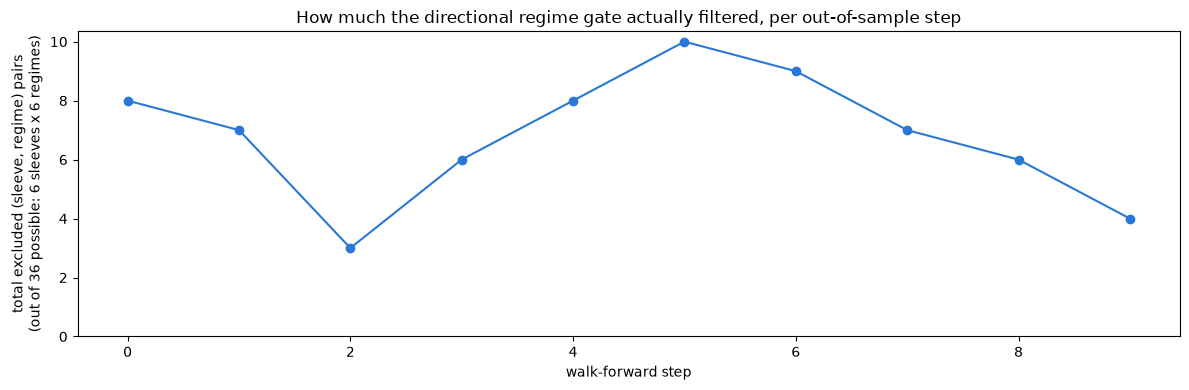

total_excluded_regimes across steps: min=3, max=10, mean=6.8


In [9]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(wf_results["step"], wf_results["total_excluded_regimes"], marker="o", color="#2a78d6")
ax.set_xlabel("walk-forward step")
ax.set_ylabel("total excluded (sleeve, regime) pairs\n(out of 36 possible: 6 sleeves x 6 regimes)")
ax.set_title("How much the directional regime gate actually filtered, per out-of-sample step")
ax.set_ylim(bottom=0)
fig.tight_layout()
plt.show()

print(f"total_excluded_regimes across steps: min={wf_results['total_excluded_regimes'].min()}, "
      f"max={wf_results['total_excluded_regimes'].max()}, mean={wf_results['total_excluded_regimes'].mean():.1f}")

## Findings

**Same verdict as the direction-agnostic gate: the directional version also
does not survive walk-forward. If anything, it does slightly worse on the
test that actually matters.**

| | trades | trade_sharpe_lb |
|---|---|---|
| Filtered (directional regime-gated OOS) | 3,659 | **+0.0686** |
| Unfiltered (OOS) | 4,409 | **+0.0645** |

At first glance this looks like a repeat of the original story (filtered
edges out unfiltered on the pooled trade-level lower bound, +0.0686 vs
+0.0645) -- but this time the **paired step-level test**, run correctly
from the start (not as a correction after the fact, this time), tells a
clearer story than the raw pooled numbers do:

- Mean per-step difference (filtered - unfiltered): **-1.57 percentage
  points** -- filtered was *worse* on average, not better.
- Paired t-test: t=-1.714, p=0.121 -- not significant, but leaning the
  wrong way and closer to significance than the original 4-regime version's
  p=0.816.
- Wilcoxon signed-rank: p=0.275 -- also not significant.
- **Filtered beat unfiltered in only 3 of 10 steps** -- worse than the
  original 4-regime gate's already-unimpressive 5/10 coin flip.

**Why the pooled trade-level number and the paired step-level number
disagree**: the pooled `trade_sharpe_lb` is dominated by whichever steps
have the most trades, and doesn't account for the fact that filtered and
unfiltered share most of their trades (same lesson as the first walk-
forward notebook, applied consistently here). The paired test is the
correct one, and it says the directional gate is not an improvement --
descriptively plausible, but it doesn't survive being re-derived fresh on
rolling windows and tested out-of-sample.

**Instability is at least as bad as before**: `total_excluded_regimes`
(out of 36 possible sleeve x regime pairs, since there are now 6 regimes
instead of 4) ranged from **3 to 10** per step (mean 6.8) -- the specific
set of "bad" regimes shifts substantially window to window, same red flag
pattern as the original gate.

**Bottom line -- this closes the loop on the whole regime-gating line of
inquiry, not just this variant.** Two different regime schemes (direction-
agnostic 4-way, directional 6-way), two different single-split-derived
gating rules (`profit_factor > 1` threshold, "top 50%"), tested three
separate ways -- all either add no significant edge or actively underperform
once walk-forward tested properly. The descriptive regime *fingerprinting*
in `strategy_performance_by_regime.ipynb` remains real and useful for
understanding mechanism behavior (e.g. melt-ups hurting Keltner/SuperTrend
more than crashes) -- but converting any of these observations into a live
gating rule keeps re-introducing the same overfitting-to-recent-history
problem, regardless of how the regime is defined. **Recommendation: stop
trying to build a regime-gated rule from this data; the unfiltered combined
6-sleeve portfolio's own walk-forward confirmation (`trade_sharpe_lb`=
+0.0645) remains the best, simplest, actually-validated result.**